<a href="https://colab.research.google.com/github/haqiaryva/Clustering/blob/main/Copy_of_KmeansV4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kneed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
!pip install kneed
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

np.random.seed(42)
sns.set_style('whitegrid')

Mounted at /content/drive


In [ ]:
df22 = pd.read_csv('/content/drive/MyDrive/GEE_Flood_Mapping/Fix/22_merged.csv')
df23 = pd.read_csv('/content/drive/MyDrive/GEE_Flood_Mapping/Fix/23_merged.csv')
df24 = pd.read_csv('/content/drive/MyDrive/GEE_Flood_Mapping/Fix/24_merged.csv')

df = pd.concat([df22, df23, df24], ignore_index=True)
print(f'Total baris: {len(df)}')
print(f'Distribusi per tahun:\n{df["year"].value_counts().sort_index()}')
print(f'Jumlah kecamatan: {df["kecamata"].nunique()}')
df.head()

Total baris: 2880
Distribusi per tahun:
year
2022    960
2023    960
2024    960
Name: count, dtype: int64
Jumlah kecamatan: 80


,system:index,NDVI,NDWI,elevation,kab_kota,kecamata,lat,lon,month,slope,year,.geo,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
0,1_1_1_1_1_1_1_1_1_1_1_0,0.218312,-0.212996,676.206101,kota Bandung,Panyileukan,-6.932290,107.706236,1,1.999909,2022,"{""type"":""Point"",""coordinates"":[107.70623577014...",8043,59.5,5,1,163.000000,2.451523
1,1_1_1_1_1_1_1_1_1_1_1_1,0.227672,-0.224412,676.313204,kota Bandung,Cinambo,-6.927507,107.691675,1,2.013278,2022,"{""type"":""Point"",""coordinates"":[107.69167504820...",7019,59.5,5,1,163.000000,2.596060
2,1_1_1_1_1_1_1_1_1_1_1_2,0.230442,-0.241433,744.067220,kota Bandung,Ujungberung,-6.905399,107.705491,1,6.691497,2022,"{""type"":""Point"",""coordinates"":[107.70549126252...",14294,59.5,5,3,155.000000,1.267933
3,1_1_1_1_1_1_1_1_1_1_1_3,0.220469,-0.207537,665.120285,kota Bandung,Gedebage,-6.953342,107.697337,1,1.068354,2022,"{""type"":""Point"",""coordinates"":[107.69733645486...",4441,59.5,5,2,163.000000,3.507375
4,1_1_1_1_1_1_1_1_1_1_1_4,0.281412,-0.289582,730.635398,kota Bandung,Mandalajati,-6.897673,107.672149,1,7.245589,2022,"{""type"":""Point"",""coordinates"":[107.67214927144...",11188,59.5,5,1,162.557312,0.801085


In [ ]:
features = [
    'NDVI', 'NDWI',
    'elevation', 'slope',
    'kepadatan',
    'rainfall',
    'TEXTURE_USDA', 'DRAINAGE', 'AWC',
    'GFI'
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape: {X.shape}')
pd.DataFrame(X_scaled, columns=features).describe().round(3)

Shape: (2880, 10)


,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
count,2880.000,2880.000,2880.000,2880.000,2880.000,2880.000,2880.000,2880.000,2880.000,2880.000
mean,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.707,-2.675,-2.076,-1.221,-1.002,-1.305,-0.484,-1.552,-4.022,-1.560
25%,-0.823,-0.716,-0.621,-0.992,-0.817,-0.856,-0.484,-0.665,-0.261,-0.884
50%,-0.127,-0.007,-0.419,-0.232,-0.322,-0.197,-0.484,0.813,0.226,0.028
75%,0.725,0.835,0.198,1.019,0.528,0.784,-0.484,0.813,0.620,0.824
max,2.912,1.870,3.457,1.820,4.101,2.796,3.240,0.813,1.467,1.994


### PCA

In [ ]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print(f"PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

PC1: 47.09%
PC2: 17.07%
Total: 64.16%


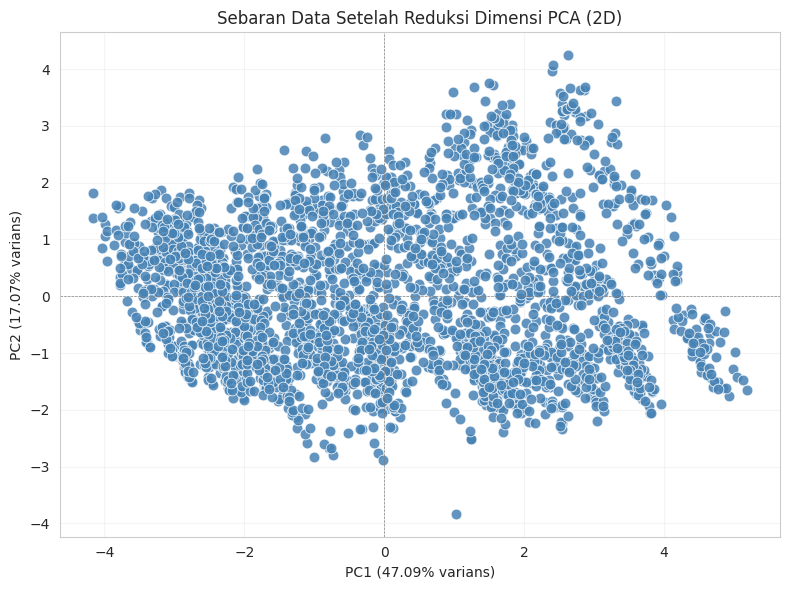

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=60, color='steelblue',
           edgecolor='white', linewidth=0.6, alpha=0.85)

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% varians)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% varians)")
ax.set_title("Sebaran Data Setelah Reduksi Dimensi PCA (2D)")
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Jumlah klaster optimal : 4


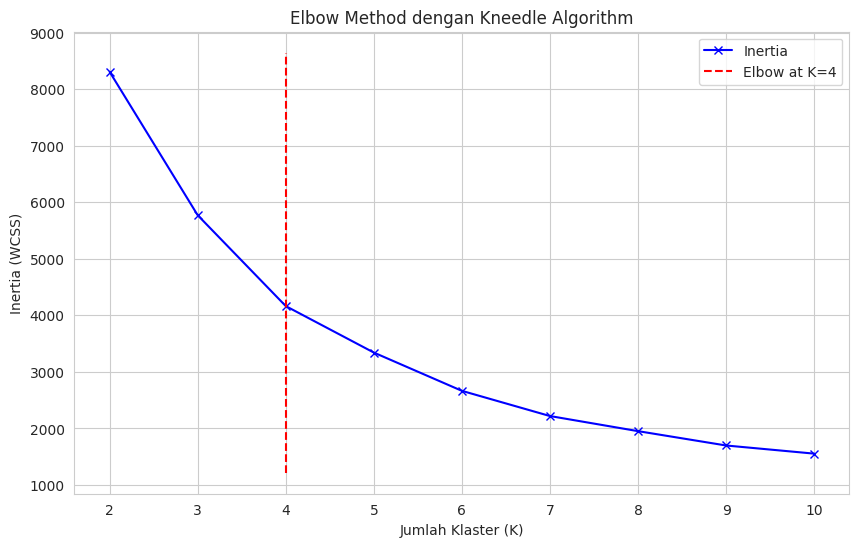

In [ ]:
K_range = range(2, 11)
inertias = []

# 1. Loop untuk menghitung inertia
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_2d)
    inertias.append(kmeans.inertia_)

# 2. Mencari titik elbow otomatis dengan Kneedle
kn = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = kn.knee

print(f'Jumlah klaster optimal : {optimal_k}')

# 3. Visualisasi
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bx-', label='Inertia')
if optimal_k:
    plt.vlines(optimal_k, plt.ylim()[0], plt.ylim()[1], linestyles='--', colors='r', label=f'Elbow at K={optimal_k}')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method dengan Kneedle Algorithm')
plt.xticks(K_range)
plt.legend()
plt.grid(True)
plt.show()

,Jumlah Klaster (K),Silhouette Score
0,2,0.3250
1,3,0.3008
2,4,0.2011
3,5,0.2030
4,6,0.1765
5,7,0.1702
6,8,0.1654
7,9,0.1604
8,10,0.1458



Jumlah klaster optimal : 2


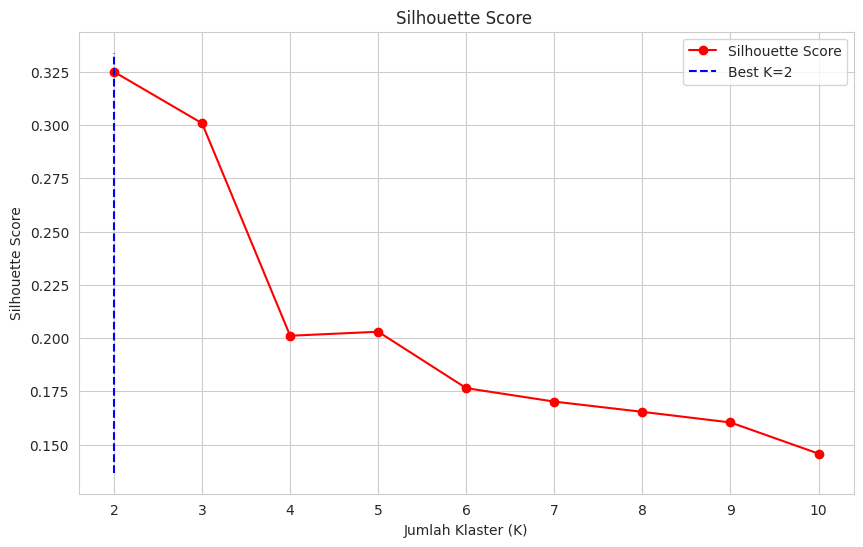

In [ ]:
K_range = range(2, 11)
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_2d)
    silhouettes.append(silhouette_score(X_scaled, labels))

optimal_k_sil = list(K_range)[np.argmax(silhouettes)]

df_scores = pd.DataFrame({
    'Jumlah Klaster (K)': list(K_range),
    'Silhouette Score': silhouettes
})
display(df_scores.round(4))
print(f'\nJumlah klaster optimal : {optimal_k_sil}')

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouettes, 'ro-', label='Silhouette Score')
if optimal_k_sil:
    plt.vlines(optimal_k_sil, plt.ylim()[0], plt.ylim()[1], linestyles='--', colors='blue', label=f'Best K={optimal_k_sil}')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score ')
plt.xticks(K_range)
plt.legend()
plt.grid(True)
plt.show()

### Clustering & Evaluasi (PCA)

Shape: (2880, 10) -> (2880, 2)
    K   Inertia  Sil_PCA  Sil_Asli
0   2  8307.785    0.472     0.325
1   3  5771.142    0.460     0.301
2   4  4163.998    0.400     0.201
3   5  3341.634    0.404     0.203
4   6  2664.642    0.392     0.177
5   7  2219.053    0.393     0.170
6   8  1951.904    0.394     0.165
7   9  1698.137    0.401     0.161
8  10  1554.209    0.389     0.146
Elbow Method       -> K = 4
Silhouette tertinggi -> K = 2 (score = 0.4724)


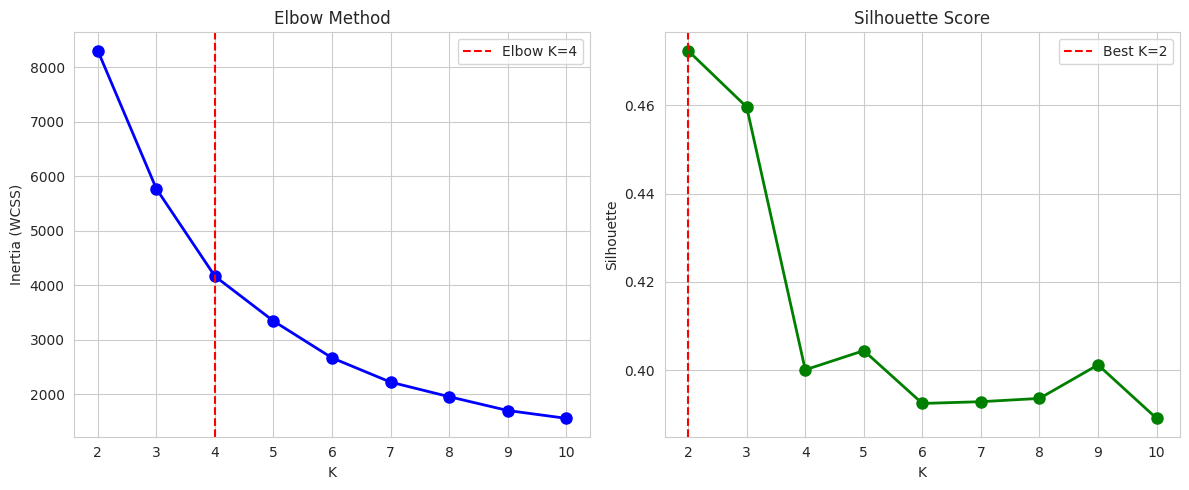

In [ ]:
X_pca = X_2d
print(f'Shape: {X_scaled.shape} -> {X_pca.shape}')
k_range = range(2, 11)
inertia, sil_pca, sil_orig = [], [], []
for k in k_range:
  km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
  labels = km.fit_predict(X_pca)
  inertia.append(km.inertia_)
  sil_pca.append(silhouette_score(X_pca, labels))
  sil_orig.append(silhouette_score(X_scaled, labels))
hasil = pd.DataFrame({
  'K': list(k_range),
  'Inertia': inertia,
  'Sil_PCA': sil_pca,
  'Sil_Asli': sil_orig
})
print(hasil.round(3))
kl = KneeLocator(list(k_range), inertia, curve='convex', direction='decreasing')
elbow_k = kl.knee
best_sil_k = list(k_range)[int(np.argmax(sil_pca))]
print(f'Elbow Method       -> K = {elbow_k}')
print(f'Silhouette tertinggi -> K = {best_sil_k} (score = {max(sil_pca):.4f})')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(list(k_range), inertia, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(elbow_k, color='red', linestyle='--', label=f'Elbow K={elbow_k}')
axes[0].set(xlabel='K', ylabel='Inertia (WCSS)', title='Elbow Method')
axes[0].legend()
axes[1].plot(list(k_range), sil_pca, 'go-', linewidth=2, markersize=8)
axes[1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best K={best_sil_k}')
axes[1].set(xlabel='K', ylabel='Silhouette', title='Silhouette Score')
axes[1].legend()
plt.tight_layout()
plt.show()

### Penerapan Kmeans


 elbow

In [ ]:
optimal = elbow_k

final_km = KMeans(n_clusters=optimal, random_state=42, n_init=10)
df['cluster'] = final_km.fit_predict(X_pca)

print(f'\nDistribusi per cluster:')
print(df['cluster'].value_counts().sort_index())
display(df[['kecamata', 'year', 'cluster'] + features].head())


Distribusi per cluster:
cluster
0    562
1    894
2    733
3    691
Name: count, dtype: int64


,kecamata,year,cluster,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
0,Panyileukan,2022,1,0.218312,-0.212996,676.206101,1.999909,8043,59.5,5,1,163.000000,2.451523
1,Cinambo,2022,2,0.227672,-0.224412,676.313204,2.013278,7019,59.5,5,1,163.000000,2.596060
2,Ujungberung,2022,2,0.230442,-0.241433,744.067220,6.691497,14294,59.5,5,3,155.000000,1.267933
3,Gedebage,2022,2,0.220469,-0.207537,665.120285,1.068354,4441,59.5,5,2,163.000000,3.507375
4,Mandalajati,2022,2,0.281412,-0.289582,730.635398,7.245589,11188,59.5,5,1,162.557312,0.801085


 silhoutte

In [ ]:
optimal = best_sil_k

final_km_sil = KMeans(n_clusters=optimal, random_state=42, n_init=10)
df['cluster_sil'] = final_km_sil.fit_predict(X_pca)

print(f'\nDistribusi per cluster :')
print(df['cluster_sil'].value_counts().sort_index())
display(df[['kecamata', 'year', 'cluster_sil'] + features].head())


Distribusi per cluster :
cluster_sil
0    1617
1    1263
Name: count, dtype: int64


,kecamata,year,cluster_sil,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
0,Panyileukan,2022,0,0.218312,-0.212996,676.206101,1.999909,8043,59.5,5,1,163.000000,2.451523
1,Cinambo,2022,0,0.227672,-0.224412,676.313204,2.013278,7019,59.5,5,1,163.000000,2.596060
2,Ujungberung,2022,0,0.230442,-0.241433,744.067220,6.691497,14294,59.5,5,3,155.000000,1.267933
3,Gedebage,2022,0,0.220469,-0.207537,665.120285,1.068354,4441,59.5,5,2,163.000000,3.507375
4,Mandalajati,2022,0,0.281412,-0.289582,730.635398,7.245589,11188,59.5,5,1,162.557312,0.801085


### Visualisasi

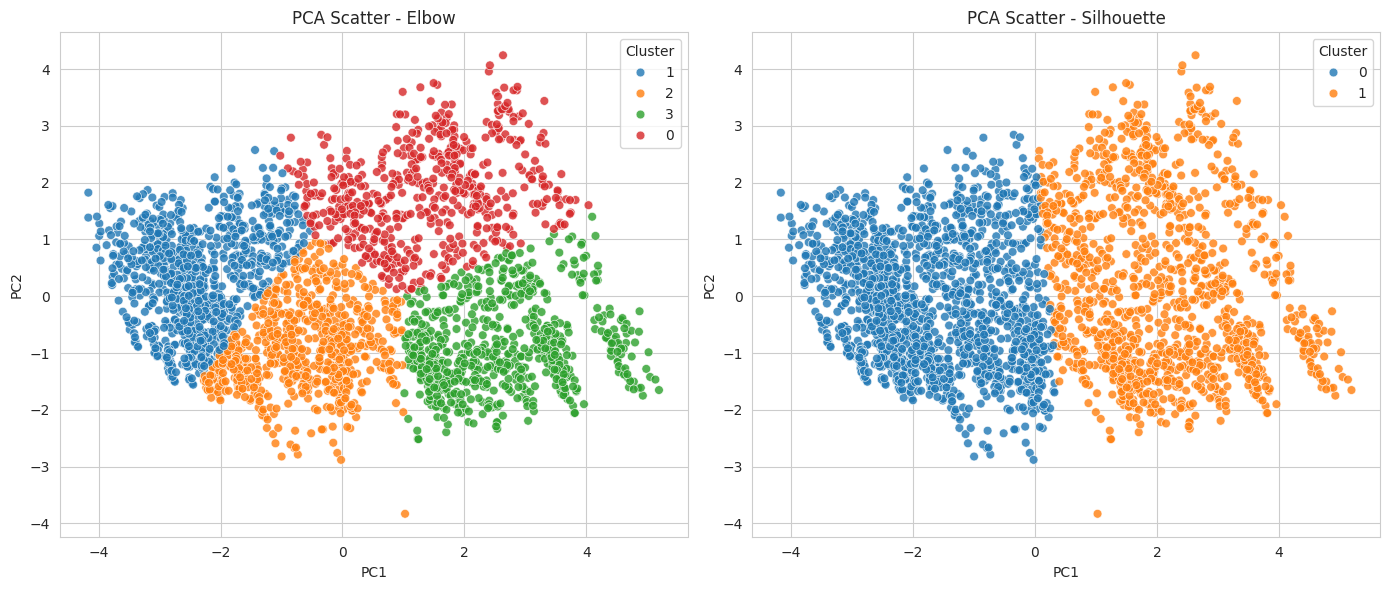

In [ ]:
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['cluster']     = KMeans(n_clusters=elbow_k, init='k-means++', n_init=10, random_state=42).fit_predict(X_pca)
df['cluster_sil'] = KMeans(n_clusters=best_sil_k, init='k-means++', n_init=10, random_state=42).fit_predict(X_pca)
configs = [
  ('cluster',     elbow_k,    'Elbow'),
  ('cluster_sil', best_sil_k, 'Silhouette')

]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (col, k, title) in zip(axes, configs):
    sns.scatterplot(x='PC1', y='PC2', hue=df[col].astype(str), palette='tab10', data=df, s=40, alpha=0.8, ax=ax)
    ax.set_title(f'PCA Scatter - {title}')
    ax.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

### Karakteristik Cluster


K = 4

In [ ]:
profile = df.groupby('cluster')[features].mean().round(2)
profile

,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
cluster,,,,,,,,,,
0,0.18,-0.15,1049.75,13.56,2787.72,255.57,6.38,2.94,153.83,0.10
1,0.13,-0.14,696.97,2.65,16365.05,210.70,5.00,1.46,161.36,2.41
2,0.33,-0.34,720.37,4.39,9282.12,119.69,5.02,2.27,158.89,1.94
3,0.55,-0.50,999.77,14.00,2000.69,119.48,6.57,2.95,153.35,0.13


In [ ]:
fitur_kategorikal = ['TEXTURE_USDA', 'DRAINAGE']
fitur_kontinu = [f for f in features if f not in fitur_kategorikal]

# Fitur kontinu -> mean ; fitur kategorikal -> modus (nilai paling sering muncul)
profil_kontinu = df.groupby('cluster')[fitur_kontinu].mean().round(3)
profil_kategorik = df.groupby('cluster')[fitur_kategorikal].agg(lambda x: x.mode().iloc[0])

# Gabungkan kembali sesuai urutan kolom 'features'
profil = pd.concat([profil_kontinu, profil_kategorik], axis=1)[features]

print('Profil tiap cluster (kontinu=mean, TEXTURE_USDA & DRAINAGE=modus):')
profil

Profil tiap cluster (kontinu=mean, TEXTURE_USDA & DRAINAGE=modus):


,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
cluster,,,,,,,,,,
0,0.181,-0.148,1049.753,13.557,2787.724,255.569,5,3,153.829,0.099
1,0.129,-0.138,696.968,2.647,16365.048,210.697,5,1,161.357,2.407
2,0.332,-0.337,720.366,4.386,9282.123,119.688,5,3,158.888,1.939
3,0.551,-0.501,999.774,13.995,2000.692,119.483,5,3,153.353,0.132


K = 2

In [ ]:
profile = df.groupby('cluster_sil')[features].mean().round(2)
profile

,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
cluster_sil,,,,,,,,,,
0,0.21,-0.21,707.46,3.42,13218.88,176.92,5.01,1.82,160.25,2.20
1,0.40,-0.36,1019.77,13.73,2381.94,171.19,6.47,2.95,153.61,0.13


In [ ]:
fitur_kategorikal = ['TEXTURE_USDA', 'DRAINAGE']
fitur_kontinu = [f for f in features if f not in fitur_kategorikal]

# Fitur kontinu -> mean ; fitur kategorikal -> modus (nilai paling sering muncul)
profil_kontinu = df.groupby('cluster_sil')[fitur_kontinu].mean().round(3)
profil_kategorik = df.groupby('cluster_sil')[fitur_kategorikal].agg(lambda x: x.mode().iloc[0])

# Gabungkan kembali sesuai urutan kolom 'features'
profil = pd.concat([profil_kontinu, profil_kategorik], axis=1)[features]

print('Profil tiap cluster (kontinu=mean, TEXTURE_USDA & DRAINAGE=modus):')
profil

Profil tiap cluster (kontinu=mean, TEXTURE_USDA & DRAINAGE=modus):


,NDVI,NDWI,elevation,slope,kepadatan,rainfall,TEXTURE_USDA,DRAINAGE,AWC,GFI
cluster_sil,,,,,,,,,,
0,0.206,-0.212,707.457,3.419,13218.882,176.920,5,1,160.252,2.199
1,0.403,-0.362,1019.767,13.730,2381.944,171.185,5,3,153.610,0.130


### Analisis dengan Elbow

Per bulan dalam 1 Tahun

In [ ]:
pivot_bulan = df.pivot_table(
    index=['kecamata', 'year'], columns='month', values='cluster', aggfunc='first'
).reset_index()
pivot_bulan.columns = ['kecamatan', 'tahun'] + [f'bln_{m}' for m in range(1, 13)]

# Hitung perubahan & cluster unik
def hitung_perubahan(row):
    vals = [row[f'bln_{m}'] for m in range(1, 13)]
    perubahan = sum(1 for i in range(1, 12) if vals[i] != vals[i-1])
    return pd.Series({'jml_perubahan': perubahan, 'jml_cluster_unik': len(set(vals))})

stats = pivot_bulan.apply(hitung_perubahan, axis=1)
pivot_bulan = pd.concat([pivot_bulan, stats], axis=1)
pivot_bulan['stabil'] = pivot_bulan['jml_cluster_unik'].apply(lambda x: 'Ya' if x == 1 else 'Tidak')

n_stabil = (pivot_bulan['stabil'] == 'Ya').sum()
n_total = len(pivot_bulan)
print(f'Stabil sepanjang tahun: {n_stabil}/{n_total} ({n_stabil/n_total*100:.1f}%)')
print(f'Berubah cluster      : {n_total-n_stabil}/{n_total} ({(n_total-n_stabil)/n_total*100:.1f}%)')

pivot_bulan.to_csv('/content/drive/MyDrive/GEE_Flood_Mapping/PCA/0,31/Elbow/perubahan_cluster_antar_bulan.csv', index=False)

print(f'\nContoh - Panyileukan:')
pivot_bulan[pivot_bulan['kecamatan'] == 'Bojongsoang']

Stabil sepanjang tahun: 36/240 (15.0%)
Berubah cluster      : 204/240 (85.0%)

Contoh - Panyileukan:


,kecamatan,tahun,bln_1,bln_2,bln_3,bln_4,bln_5,bln_6,bln_7,bln_8,bln_9,bln_10,bln_11,bln_12,jml_perubahan,jml_cluster_unik,stabil
45,Bojongsoang,2022,1,1,1,1,1,1,2,2,2,1,1,1,2,2,Tidak
46,Bojongsoang,2023,1,1,2,2,1,2,2,2,2,2,1,1,4,2,Tidak
47,Bojongsoang,2024,1,1,2,2,2,2,2,2,2,2,1,2,3,2,Tidak


Per tahun

In [ ]:
dominan = (
    df.groupby(['kecamata', 'year'])['cluster']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={'cluster': 'cluster_dominan'})
)
pivot_tahun = dominan.pivot(index='kecamata', columns='year', values='cluster_dominan').reset_index()
pivot_tahun.columns = ['kecamatan'] + [f'cluster_{y}' for y in sorted(df['year'].unique())]

pivot_tahun['status_antar_tahun'] = pivot_tahun.apply(
    lambda r: 'Tetap' if len(set([r[f'cluster_{y}'] for y in sorted(df['year'].unique())])) == 1 else 'Berubah',
    axis=1
)

n_tetap = (pivot_tahun['status_antar_tahun'] == 'Tetap').sum()
print(f'Kecamatan TETAP cluster 2022-2024 : {n_tetap}/{len(pivot_tahun)} ({n_tetap/len(pivot_tahun)*100:.1f}%)')
print(f'Kecamatan BERUBAH cluster         : {len(pivot_tahun)-n_tetap}')

pivot_tahun.to_csv('/content/drive/MyDrive/GEE_Flood_Mapping/PCA/0,31/Elbow/perubahan_cluster_antar_tahun.csv', index=False)

print(f'\nContoh - Panyileukan:')
pivot_tahun[pivot_tahun['kecamatan'] == 'Cimahi Selatan']

Kecamatan TETAP cluster 2022-2024 : 38/80 (47.5%)
Kecamatan BERUBAH cluster         : 42

Contoh - Panyileukan:


,kecamatan,cluster_2022,cluster_2023,cluster_2024,status_antar_tahun
30,Cimahi Selatan,1,2,2,Berubah


### Analisis dengan Silhouette

per bulan

In [ ]:
pivot_bulan = df.pivot_table(
    index=['kecamata', 'year'], columns='month', values='cluster_sil', aggfunc='first'
).reset_index()
pivot_bulan.columns = ['kecamatan', 'tahun'] + [f'bln_{m}' for m in range(1, 13)]

# Hitung perubahan & cluster unik
def hitung_perubahan(row):
    vals = [row[f'bln_{m}'] for m in range(1, 13)]
    perubahan = sum(1 for i in range(1, 12) if vals[i] != vals[i-1])
    return pd.Series({'jml_perubahan': perubahan, 'jml_cluster_unik': len(set(vals))})

stats = pivot_bulan.apply(hitung_perubahan, axis=1)
pivot_bulan = pd.concat([pivot_bulan, stats], axis=1)
pivot_bulan['stabil'] = pivot_bulan['jml_cluster_unik'].apply(lambda x: 'Ya' if x == 1 else 'Tidak')

n_stabil = (pivot_bulan['stabil'] == 'Ya').sum()
n_total = len(pivot_bulan)
print(f'Stabil sepanjang tahun: {n_stabil}/{n_total} ({n_stabil/n_total*100:.1f}%)')
print(f'Berubah cluster      : {n_total-n_stabil}/{n_total} ({(n_total-n_stabil)/n_total*100:.1f}%)')

pivot_bulan.to_csv('/content/drive/MyDrive/GEE_Flood_Mapping/PCA/0,31/Sil/perubahan_cluster_antar_bulan.csv', index=False)

print(f'\nContoh - Panyileukan:')
pivot_bulan[pivot_bulan['kecamatan'] == 'Bojongsoang']

Stabil sepanjang tahun: 211/240 (87.9%)
Berubah cluster      : 29/240 (12.1%)

Contoh - Panyileukan:


,kecamatan,tahun,bln_1,bln_2,bln_3,bln_4,bln_5,bln_6,bln_7,bln_8,bln_9,bln_10,bln_11,bln_12,jml_perubahan,jml_cluster_unik,stabil
45,Bojongsoang,2022,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Ya
46,Bojongsoang,2023,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Ya
47,Bojongsoang,2024,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Ya


per tahun

In [ ]:
dominan = (
    df.groupby(['kecamata', 'year'])['cluster_sil']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={'cluster_sil': 'cluster_dominan'})
)
pivot_tahun = dominan.pivot(index='kecamata', columns='year', values='cluster_dominan').reset_index()
pivot_tahun.columns = ['kecamatan'] + [f'cluster_{y}' for y in sorted(df['year'].unique())]

pivot_tahun['status_antar_tahun'] = pivot_tahun.apply(
    lambda r: 'Tetap' if len(set([r[f'cluster_{y}'] for y in sorted(df['year'].unique())])) == 1 else 'Berubah',
    axis=1
)

n_tetap = (pivot_tahun['status_antar_tahun'] == 'Tetap').sum()
print(f'Kecamatan TETAP cluster 2022-2024 : {n_tetap}/{len(pivot_tahun)} ({n_tetap/len(pivot_tahun)*100:.1f}%)')
print(f'Kecamatan BERUBAH cluster         : {len(pivot_tahun)-n_tetap}')

pivot_tahun.to_csv('/content/drive/MyDrive/GEE_Flood_Mapping/PCA/0,31/Sil/perubahan_cluster_antar_tahun.csv', index=False)

print(f'\nContoh - Panyileukan:')
pivot_tahun[pivot_tahun['kecamatan'] == 'Cimahi Selatan']

Kecamatan TETAP cluster 2022-2024 : 77/80 (96.2%)
Kecamatan BERUBAH cluster         : 3

Contoh - Panyileukan:


,kecamatan,cluster_2022,cluster_2023,cluster_2024,status_antar_tahun
30,Cimahi Selatan,0,0,0,Tetap


eksperimen

In [ ]:
!pip freeze > requirements_full.txt

# Filter hanya paket yang dipakai aplikasi Streamlit
import re
keep = ['streamlit','pca','scikit-learn','numpy','pandas',
        'scipy','numba','joblib','plotly','matplotlib','seaborn','kneed']
with open('requirements_full.txt') as f, open('requirements.txt','w') as out:
    for line in f:
        name = re.split('[=<>]', line)[0].strip().lower()
        if name in keep:
            out.write(line)

print(open('requirements.txt').read())

from google.colab import files
files.download('requirements.txt')

In [ ]:
import pickle
import json

# 1. SIMPAN MODEL
with open('kmeans_elbow(0,31).pkl', 'wb') as f:
    pickle.dump(final_km, f)

with open('kmeans_silhouette(0,31).pkl', 'wb') as f:
    pickle.dump(final_km_sil, f)

# 2. SIMPAN SCALER
with open('scaler(0,31).pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. SIMPAN PCA (pengganti UMAP)
with open('pca_reducer(0,31).pkl', 'wb') as f:
    pickle.dump(pca_2d, f)

# 4. SIMPAN PROFIL CLUSTER
with open('cluster_summaries(0,31).pkl', 'wb') as f:
    pickle.dump(profil, f)

with open('cluster_summaries(0,31).txt', 'w') as f:
    f.write(json.dumps(profil.to_dict(), indent=4))

# 5. SIMPAN DATA HASIL
cols_out = ['kecamata', 'year', 'month'] + features + ['cluster', 'cluster_sil']
df[cols_out].to_csv('main_data_with_pred(0,31).csv', index=False)

print("Semua model berhasil diekspor!")

Semua model berhasil diekspor!
